# Purpose

This notebook generates main figures in the Results (Fig 4-8).

In [1]:
import pickle
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from scripts import draw

In [2]:
cond_ls = ['A', 'C'] # Weight adjustment condition
eta = 10.0 # learning rate
K = 30 # number of instances

num_bins = 20 # number of bins on the logscale for the histogram of the upper tail of the weight distribution

k_rep = 0 # the index of the representative network

# Control conditions

## Fig 4: Histogram of weight distributions and power-law fits

In [3]:
# Import representative networks
tau_ls = [0.05, 0.1, 0.5]
A_wAdjAlone = {}
for cond in cond_ls:
    A_wAdjAlone[cond] = {}
    for tau in tau_ls:
        f = open('./Output/wAdjust_alone/'+cond+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k_rep)+'.pckl', 'rb')
        A_wAdjAlone[cond][tau], _ = pickle.load(f)
        f.close()

# Import coefficients of power-law fits
f = open('./Output/wAdjust_alone/PL_fit.pckl', 'rb')
res_PL, PL_expon = pickle.load(f)
f.close()

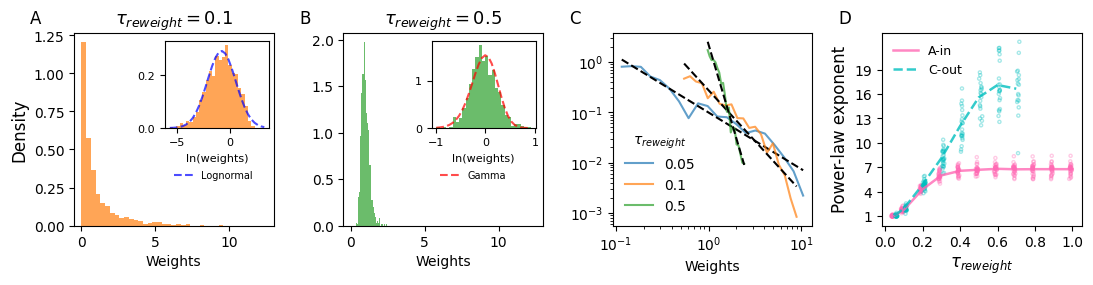

In [4]:
plt.rcParams["figure.figsize"] = (13, 2.5)
fig, ax1 = plt.subplots(1, 4)

cond = 'A'
# Histograms of the representative networks from the A-in condition
for l, tau in enumerate([0.1, 0.5]):
    weights = A_wAdjAlone[cond][tau][A_wAdjAlone[cond][tau]>0]
    ax1[l].hist(weights, bins=30, density=True,color = sns.color_palette(palette='tab10', n_colors=3)[l+1], alpha=0.7)
    ax1[l].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
    ax1[l].set_xlabel('Weights',fontsize=10)
    ax1[l].tick_params(axis = 'both', labelsize=10)
    ax1[l].set_xlim([-0.5, 13])
    
    # histogram of log(weights)
    left, bottom, width, height = [0.195+l*0.205, 0.5, 0.08, 0.35]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    x, mu, sig = draw.hist_log_weight(ax1_1, weights, num_bins = 30, color = sns.color_palette(palette='tab10', n_colors=3)[l+1])
    # the best fit distribution
    if l == 0:
        ylog = stats.norm.pdf(x, loc=mu, scale=sig)
        ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
    else:
        a, loc, scale = stats.gamma.fit(weights, floc = 0)
        yig = stats.gamma.pdf(np.exp(x), a, loc, scale) * np.exp(x)
        ax1_1.plot(x, yig, color='r', linestyle='dashed',alpha=0.7, label = 'Gamma')
    ax1_1.legend(fontsize = 7, bbox_to_anchor=[0, -0.7], loc='lower left', frameon=False)
ax1[0].set_ylabel('Density',fontsize=12)

# Draw power-law fits of the representative networks
for l, tau in enumerate([0.05, 0.1, 0.5]):
    weights = A_wAdjAlone[cond][tau][A_wAdjAlone[cond][tau]>0]
    res = res_PL[cond][tau].iloc[k_rep]
    draw.draw_power_law(ax1[2], weights, res, tau, num_bins, color=sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit=True)
ax1[2].set_xscale('log')
ax1[2].set_yscale('log')
ax1[2].legend(title = '$\\tau_{reweight}$', frameon=False)
ax1[2].set_xlabel('Weights',fontsize=10)

# The decay rates across tau_reweight of all instances
cond_color = ['hotpink', 'c']; cond_label = ['A-in', 'C-out']; cond_linestyle = ['-', '--']
for s, cond in enumerate(cond_ls):
    draw.draw_mean_scatter(ax1[3], list(PL_expon[cond].keys()), PL_expon[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)

ax1[3].legend(fontsize=9, frameon=False)
ax1[3].set_xticks(np.arange(0, 1.2, 0.2))
ax1[3].set_yticks(np.arange(1, 22, 3))
ax1[3].set_xlabel('$\\tau_{reweight}$', fontsize = 12)
ax1[3].set_ylabel('Power-law exponent', fontsize = 12)
ax1[0].text(-0.22, 1.05, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'B', transform=ax1[1].transAxes, size=12)
ax1[2].text(-0.22, 1.05, 'C', transform=ax1[2].transAxes, size=12)
ax1[3].text(-0.22, 1.05, 'D', transform=ax1[3].transAxes, size=12)

fig.subplots_adjust(wspace = 0.35)
#plt.savefig('../fig/Fig 4.svg', dpi = 300)

## Fig 5: Connectivity metrics

In [5]:
# Import connectivity metrics
f = open('./Output/wAdjust_alone/Topo_metrics.pckl', 'rb')
cc_null_norm, ae_null_norm, sw_null_norm, mod_null_norm = pickle.load(f)
f.close()

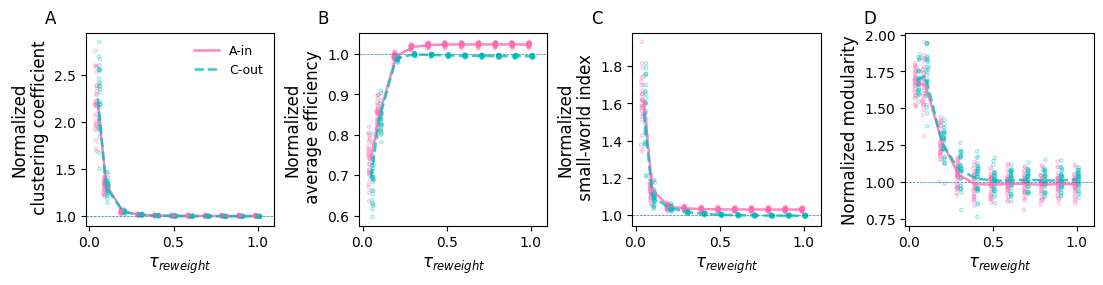

In [6]:
tau_ls = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
cond_color = ['hotpink', 'c']; cond_label = ['A-in', 'C-out']; cond_linestyle = ['-', '--']

plt.rcParams["figure.figsize"] = (13, 2.5)
fig, ax1 = plt.subplots(1, 4)

for s, cond in enumerate(cond_ls):
    draw.draw_mean_scatter(ax1[0], tau_ls, cc_null_norm[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)
    draw.draw_mean_scatter(ax1[1], tau_ls, ae_null_norm[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)
    draw.draw_mean_scatter(ax1[2], tau_ls, sw_null_norm[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)
    draw.draw_mean_scatter(ax1[3], tau_ls, mod_null_norm[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)

for l in range(4):
    ax1[l].axhline(y = 1, ls = '--', lw = 0.5)
    ax1[l].set_xlim([-0.02,1.1])
    ax1[l].set_xlabel('$\\tau_{reweight}$', fontsize = 12)
ax1[0].legend(fontsize=9, frameon=False)
ax1[0].set_ylabel('Normalized\n clustering coefficient', fontsize = 12)
ax1[1].set_ylabel('Normalized\n average efficiency', fontsize = 12)
ax1[2].set_ylabel('Normalized\n small-world index', fontsize = 12)
ax1[3].set_ylabel('Normalized modularity', fontsize = 12)
ax1[0].text(-0.22, 1.05, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'B', transform=ax1[1].transAxes, size=12)
ax1[2].text(-0.22, 1.05, 'C', transform=ax1[2].transAxes, size=12)
ax1[3].text(-0.22, 1.05, 'D', transform=ax1[3].transAxes, size=12)

fig.subplots_adjust( wspace = 0.45)
#plt.savefig('../fig/Fig 5.svg', dpi = 300)

# Dual adaptive algorithm

In [7]:
# Import representative networks
tau_ls = [0.05, 0.1, 0.5]
pin_ls = [0.3, 0.5, 0.7]

A_dualAdapt = {}
for cond in cond_ls:
    A_dualAdapt[cond] = {}
    for tau in tau_ls:
        A_dualAdapt[cond][tau] = {}
        for pin in pin_ls:
            f = open('./Output/dualAdapt/'+cond+'_pin_'+str(pin)+'_eta_'+str(eta)+'_tau_'+str(tau)+'_'+str(k_rep)+'.pckl', 'rb')
            A_dualAdapt[cond][tau][pin], _ = pickle.load(f)
            f.close()

## Fig 6: Histogram of weight distributions and power-law fits of A-in condition

In [8]:
pin = 0.5

f = open('./Output/dualAdapt/PL_fit_pin_'+str(pin)+'.pckl', 'rb')
res_PL, PL_expon = pickle.load(f)
f.close()

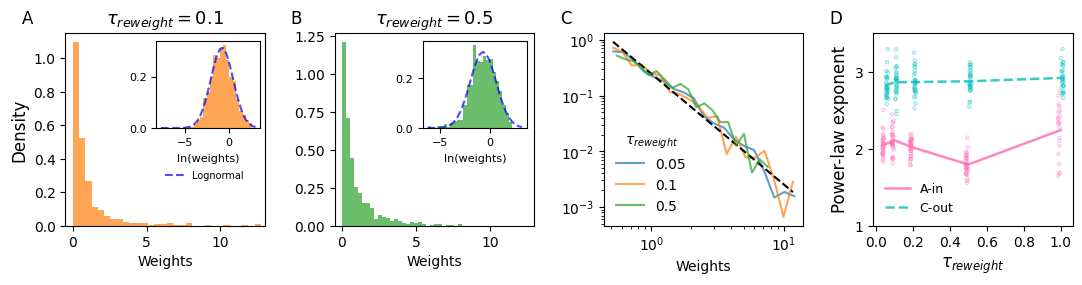

In [9]:
plt.rcParams["figure.figsize"] = (13, 2.5)
fig, ax1 = plt.subplots(1, 4)
k = 0 # the index of the representative network

cond = 'A'
# Histograms of the representative networks from the A-in condition
for l, tau in enumerate([0.1, 0.5]):
    weights = A_dualAdapt[cond][tau][pin][A_dualAdapt[cond][tau][pin]>0]
    ax1[l].hist(weights, bins=30, density=True,color = sns.color_palette(palette='tab10', n_colors=3)[l+1], alpha=0.7)
    ax1[l].set_title('$\\tau_{reweight} = $'+str(tau), fontsize = 13)
    ax1[l].set_xlabel('Weights',fontsize=10)
    ax1[l].tick_params(axis = 'both', labelsize=10)
    ax1[l].set_xlim([-0.5, 13])

    # histogram of log(weights)
    left, bottom, width, height = [0.195+l*0.205, 0.5, 0.08, 0.35]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    x, mu, sig = draw.hist_log_weight(ax1_1, weights, num_bins = 30, color = sns.color_palette(palette='tab10', n_colors=3)[l+1])
    # the best fit distribution
    ylog = stats.norm.pdf(x, loc=mu, scale=sig)    
    ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
    if l == 0:
        ax1_1.legend(fontsize = 7, bbox_to_anchor=[0, -0.7], loc='lower left', frameon=False)
ax1[0].set_ylabel('Density',fontsize=12)

# Draw power-law fits of the representative networks
for l, tau in enumerate([0.05, 0.1, 0.5]): 
    weights = A_dualAdapt[cond][tau][pin][A_dualAdapt[cond][tau][pin]>0]
    res = res_PL[cond][tau].iloc[k_rep]
    draw_fit = False
    if tau == 0.1:
        draw_fit = True
    draw.draw_power_law(ax1[2], weights, res, tau, num_bins, color = sns.color_palette(palette='tab10', n_colors=5)[l], draw_fit=draw_fit)
ax1[2].set_xscale('log')
ax1[2].set_yscale('log')
ax1[2].legend(title = '$\\tau_{reweight}$', frameon=False)
ax1[2].set_xlabel('Weights',fontsize=10)

# The decay rates across tau_reweight of all instances
cond_color = ['hotpink', 'c']; cond_label = ['A-in', 'C-out']; cond_linestyle = ['-', '--']
for s, cond in enumerate(cond_ls):
    draw.draw_mean_scatter(ax1[3], list(PL_expon[cond].keys()), PL_expon[cond], color = cond_color[s], label = cond_label[s],
    linestyle = cond_linestyle[s], shift = ((-1)**s)*0.01, jitter = 0.003)

ax1[3].legend(fontsize=9, frameon=False)
ax1[3].set_ylim([1.0, 3.5])
ax1[3].set_xticks(np.arange(0, 1.2, 0.2))
ax1[3].set_yticks(np.arange(1, 4, 1))
ax1[3].set_xlabel('$\\tau_{reweight}$', fontsize = 12)
ax1[3].set_ylabel('Power-law exponent', fontsize = 12)

ax1[0].text(-0.22, 1.05, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'B', transform=ax1[1].transAxes, size=12)
ax1[2].text(-0.22, 1.05, 'C', transform=ax1[2].transAxes, size=12)
ax1[3].text(-0.22, 1.05, 'D', transform=ax1[3].transAxes, size=12)

fig.subplots_adjust(wspace = 0.35)
#plt.savefig('../fig/Fig 6.svg', dpi = 300)

## Fig 7: Histogram of weight distribution & Power-law fits of the upper tails

In [10]:
f = open('./Output/dualAdapt/PL_fit.pckl', 'rb')
res_PL, PL_expon = pickle.load(f)
f.close()

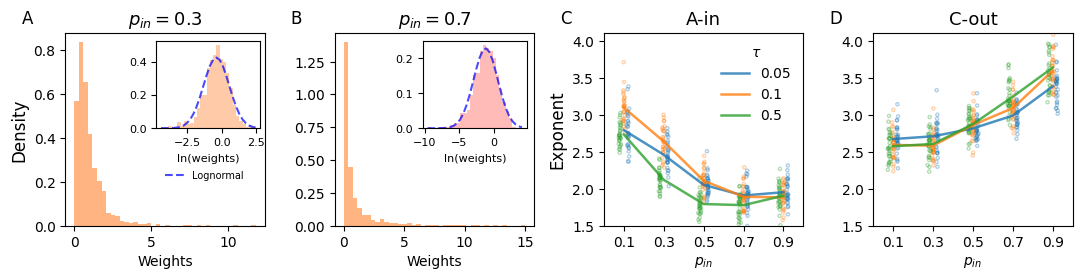

In [11]:
plt.rcParams["figure.figsize"] = (13, 2.5)
fig, ax1 = plt.subplots(1, 4)
k = 0 # the index of the representative network
# Histograms of the representative networks at tau_reweight=0.1 from A-in condition
cond = 'A'
tau = 0.1
for s, pin in enumerate([0.3, 0.7]):
    A = A_dualAdapt[cond][tau][pin].copy()
    w_sim = A[A>0]
    ax1[s].hist(w_sim, bins = 40, color = sns.color_palette(palette='pastel', n_colors=5)[1], density = True)
    ax1[s].set_title('$p_{in} = $'+str(pin), fontsize = 13)
    ax1[s].set_xlabel('Weights',fontsize=10)

    left, bottom, width, height = [0.195 + s * 0.205, 0.5, 0.08, 0.35]
    ax1_1 = fig.add_axes([left, bottom, width, height])
    x, mu, sig = draw.hist_log_weight(ax1_1, w_sim, num_bins = 30, color = sns.color_palette(palette='pastel', n_colors=5)[s*2+1])
    # the best fit distribution
    ylog = stats.norm.pdf(x, loc=mu, scale=sig)    
    ax1_1.plot(x, ylog, color='b', linestyle='dashed',alpha=0.7, label = 'Lognormal')
    if s==0:
        ax1_1.legend(fontsize = 7, frameon=False, bbox_to_anchor=[0, -0.7], loc='lower left')
ax1[0].set_ylabel('Density',fontsize=12)

# The decay rates across tau_reweight of all instances
for s, cond in enumerate(cond_ls):
    for l, tau in enumerate(tau_ls):
        draw.draw_mean_scatter(ax1[2+s], list(PL_expon[cond][tau].keys()), PL_expon[cond][tau], color = sns.color_palette(palette='tab10', n_colors=5)[l],
        label = str(tau), linestyle = '-', shift = (l-1)*0.02, jitter = 0.003)
    ax1[2+s].set_xlim([0, 1])
    ax1[2+s].set_ylim([1.5, 4.1])
    ax1[2+s].set_xticks([0.1, 0.3, 0.5, 0.7, 0.9])
    ax1[2+s].set_xlabel('$p_{in}$',fontsize=10)
ax1[2].legend(frameon = False, title = '$\\tau$')
ax1[2].set_title('A-in', fontsize=13)
ax1[3].set_title('C-out', fontsize=13)
ax1[2].set_ylabel('Exponent',fontsize=12)

ax1[0].text(-0.22, 1.05, 'A', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'B', transform=ax1[1].transAxes, size=12)
ax1[2].text(-0.22, 1.05, 'C', transform=ax1[2].transAxes, size=12)
ax1[3].text(-0.22, 1.05, 'D', transform=ax1[3].transAxes, size=12)

fig.subplots_adjust(wspace = 0.35)
#plt.savefig('../fig/Fig 7.svg', dpi = 300)

# Convergent-divergent units

## Fig 8: Ave Density of intermediate subgraphs

In [12]:
f = open('./Output/cdUnits/interm_stats.pckl', 'rb')
cd_num, cd_num_ref, subG_size, subG_size_ref, subG_density, subG_density_ref, subG_aveW, subG_aveW_ref = pickle.load(f)
f.close()

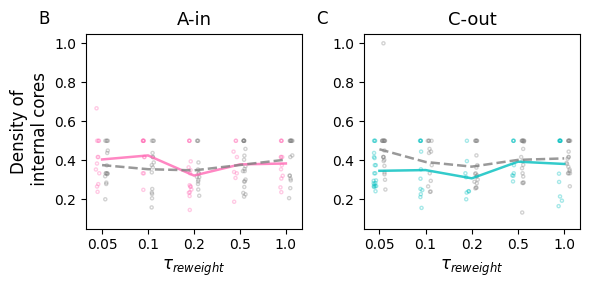

In [13]:
tau_ls = [0.05, 0.1, 0.2, 0.5, 1.0]
          
cond_color = ['hotpink', 'c']; cond_label = ['A-in', 'C-out']
n_tau = len(tau_ls)
group_centers = np.arange(1, n_tau + 1)
xtick_labels = [str(lab) for lab in tau_ls]

plt.rcParams["figure.figsize"] = (6, 3)
fig, ax1 = plt.subplots(1, 2)

for s, cond in enumerate(cond_ls):
    # average density of intermediate subgraphs of the simulated networks
    draw.draw_mean_scatter(ax1[s], group_centers, subG_density[cond], color = cond_color[s], shift = 0.1, jitter = 0.02)
    # average density of intermediate subgraphs of the null networks
    draw.draw_mean_scatter(ax1[s], group_centers, subG_density_ref[cond], color = 'grey', linestyle = '--', shift = -0.1, jitter = 0.02)
    ax1[s].set_xticks(group_centers)
    ax1[s].set_ylim([0.05, 1.05])   
    ax1[s].set_xticklabels(xtick_labels)
    ax1[s].set_xlabel('$\\tau_{reweight}$', fontsize = 12)
    ax1[s].set_title(cond_label[s], fontsize=13)

ax1[0].set_ylabel('Density of\n internal cores', fontsize = 12)
ax1[0].text(-0.22, 1.05, 'B', transform=ax1[0].transAxes, size=12)
ax1[1].text(-0.22, 1.05, 'C', transform=ax1[1].transAxes, size=12)
plt.tight_layout()
#plt.savefig('../fig/Fig 8BC.svg', dpi = 300)